# Train TabR dari POC-ABS flatten ordered (subject-held-out external)

- sumber: `output/apex/features/poc_abs_flatten_ordered.xlsx`
- external test: peserta external **tidak pernah muncul** di train/val
- internal split tetap dari sisa subject train
- output run: `output/apex/train/t1`, `t2`, dst


## v10 external harus subject-held-out\n
External dipilih berdasarkan `participant` per label, sehingga subjek external benar-benar terpisah dari subjek yang dilatih.


In [1]:
import os
import re
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'preprocess-anxiety':
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Project root: {ROOT}')


Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from joblib import dump
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from core.data_module import TabRDataModule
from core.TabR import LitTabR


class WeightedLitTabR(LitTabR):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is None:
            class_weights = torch.ones(self.hparams.num_classes, dtype=torch.float32)
        self.register_buffer('class_weights', torch.tensor(class_weights, dtype=torch.float32))
        self.loss_fn = torch.nn.CrossEntropyLoss(weight=self.class_weights)



In [3]:
FEATURES_PATH = ROOT / 'output/apex/features/poc_abs_flatten_ordered.xlsx'
TRAIN_ROOT = ROOT / 'output/apex/train'
N_EXTERNAL_PER_LABEL = 4
BATCH_SIZE = 128
MAX_EPOCHS = 50
RANDOM_SEED = 42
THRESHOLD = 0.5
LR = 3e-4
FREEZE_CONTEXT_EPOCH = MAX_EPOCHS // 4
M_NEIGHBORS = 4
EARLY_STOPPING_PATIENCE = 10

TRAIN_ROOT.mkdir(parents=True, exist_ok=True)
print(FEATURES_PATH)
print(TRAIN_ROOT)
print({'lr': LR, 'freeze_context_epoch': FREEZE_CONTEXT_EPOCH, 'm': M_NEIGHBORS, 'patience': EARLY_STOPPING_PATIENCE})


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_flatten_ordered.xlsx
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train
{'lr': 0.0003, 'freeze_context_epoch': 12, 'm': 4, 'patience': 10}


In [4]:
def get_next_train_dir(train_root: Path) -> Path:
    existing = []
    for path in train_root.iterdir():
        if path.is_dir() and re.fullmatch(r't\d+', path.name):
            existing.append(int(path.name[1:]))
    next_idx = max(existing, default=0) + 1
    out_dir = train_root / f't{next_idx}'
    out_dir.mkdir(parents=True, exist_ok=False)
    return out_dir


def plot_lightning_metrics(metrics_csv):
    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.read_csv(metrics_csv)

    if 'epoch' not in df.columns:
        raise ValueError('Kolom epoch tidak ada')

    df_epoch = (
        df.sort_values('step')
          .groupby('epoch', as_index=False)
          .last()
    )

    plt.figure()

    if 'train_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_loss'], label='Train Loss')

    if 'val_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_loss'], label='Val Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()

    if 'train_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_acc'], label='Train Accuracy')

    if 'val_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_acc'], label='Val Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


def visualize_results(model_dir, class_names=('anxiety_rendah', 'anxiety_tinggi')):
    model_dir = str(model_dir).rstrip('/')

    cm_files = {
        'Internal': os.path.join(model_dir, 'cm_internal.png'),
        'External': os.path.join(model_dir, 'cm_external.png'),
    }

    report_files = {
        'Internal': os.path.join(model_dir, 'report_internal.csv'),
        'External': os.path.join(model_dir, 'report_external.csv'),
    }

    for name, path in cm_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        img = mpimg.imread(path)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'TabR {name} Confusion Matrix')
        plt.show()

    for name, path in report_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        df = pd.read_csv(path, index_col=0)
        print(f'\n=== {name.upper()} CLASSIFICATION REPORT ===')
        print(df)


def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            prob = torch.softmax(logits, dim=1)[:, 1]
            preds = (prob > threshold).long()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, average=None)

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'support': sup,
        'cm': confusion_matrix(y_true, y_pred),
        'report': classification_report(y_true, y_pred, output_dict=True),
    }


def save_confusion_matrix(cm, labels, out_path, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def balance_context_by_label(X, y, max_per_class=None):
    idx0 = (y == 0).nonzero(as_tuple=True)[0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0]

    n = min(len(idx0), len(idx1))
    if max_per_class is not None:
        n = min(n, max_per_class)

    idx0 = idx0[torch.randperm(len(idx0))[:n]]
    idx1 = idx1[torch.randperm(len(idx1))[:n]]

    idx = torch.cat([idx0, idx1])
    idx = idx[torch.randperm(len(idx))]
    return X[idx], y[idx]


In [5]:
df = pd.read_excel(FEATURES_PATH)

label_map = {
    'anxiety_rendah': 0,
    'anxiety_tinggi': 1,
}

df = df[df['label'].isin(label_map)].copy()
df['target'] = df['label'].map(label_map)
df['event_id'] = df['phase'].astype(str) + '||' + df['participant'].astype(str) + '||' + df['question'].astype(str) + '||' + df['clip'].astype(str) + '||' + df['event_clip'].astype(str)

event_table = df[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']].drop_duplicates().reset_index(drop=True)
event_table.shape


(2763, 8)

In [6]:
def balanced_external_participants(event_table: pd.DataFrame, n_per_label: int = 4, seed: int = 42) -> set[str]:
    rng = random.Random(seed)
    participant_label_table = (
        event_table[['participant', 'label']]
        .dropna()
        .assign(participant=lambda d: d['participant'].astype(str))
        .drop_duplicates()
    )

    counts = participant_label_table.groupby('participant')['label'].nunique()
    single_label_participants = set(counts[counts == 1].index.tolist())

    eligible_participants_by_label: dict[str, list[str]] = {}
    for label_name in ['anxiety_rendah', 'anxiety_tinggi']:
        label_participants = set(
            participant_label_table.loc[participant_label_table['label'] == label_name, 'participant'].tolist()
        )
        eligible_participants = sorted(label_participants & single_label_participants)
        if len(eligible_participants) < n_per_label:
            raise ValueError(
                f'Participant eligible {label_name} kurang: butuh {n_per_label}, ada {len(eligible_participants)}'
            )
        eligible_participants_by_label[label_name] = eligible_participants

    selected_participants: set[str] = set()
    for label_name in ['anxiety_rendah', 'anxiety_tinggi']:
        picked = rng.sample(eligible_participants_by_label[label_name], n_per_label)
        selected_participants.update(picked)

    selected_ids = event_table[event_table['participant'].astype(str).isin(selected_participants)]['event_id'].tolist()
    return set(selected_ids)


external_event_ids = balanced_external_participants(event_table, N_EXTERNAL_PER_LABEL, seed=RANDOM_SEED)
df_external = df[df['event_id'].isin(external_event_ids)].copy()
df_train_all = df[~df['participant'].astype(str).isin(df_external['participant'].astype(str))].copy()

external_participants = set(df_external['participant'].astype(str).unique().tolist())
train_all_participants = set(df_train_all['participant'].astype(str).unique().tolist())
participant_overlap = sorted(external_participants & train_all_participants)
if participant_overlap:
    raise ValueError(f'External participant overlap: {participant_overlap[:10]}')

print('External events:', len(external_event_ids))
print('External rows:', df_external.shape)
print('Train rows:', df_train_all.shape)
print('External participants:', len(external_participants))
print('Train participants:', len(train_all_participants))
print('N_EXTERNAL_PER_LABEL used:', N_EXTERNAL_PER_LABEL)
print(event_table[event_table['event_id'].isin(external_event_ids)]['label'].value_counts().to_dict())
print(event_table[event_table['event_id'].isin(external_event_ids)].groupby('label')['participant'].nunique())
print(pd.crosstab(event_table[event_table['event_id'].isin(external_event_ids)]['phase'], event_table[event_table['event_id'].isin(external_event_ids)]['label']))


External events: 396
External rows: (7694, 407)
Train rows: (49962, 407)
External participants: 8
Train participants: 48
N_EXTERNAL_PER_LABEL used: 4
{'anxiety_tinggi': 200, 'anxiety_rendah': 196}
label
anxiety_rendah    4
anxiety_tinggi    4
Name: participant, dtype: int64
label   anxiety_rendah  anxiety_tinggi
phase                                 
after               99             100
before              97             100


In [7]:
meta_cols = [
    'phase', 'condition', 'label', 'participant', 'participant_raw', 'question', 'question_no',
    'sample', 'clip', 'event_clip', 'event_no', 'clip_path', 'frame', 'target', 'event_id',
]
feature_cols = [c for c in df.columns if c not in meta_cols]
print('n_features =', len(feature_cols))

def split_train_val_participants(df_train_all: pd.DataFrame, test_size: float = 0.2, seed: int = 42, max_tries: int = 200):
    participant_target = (
        df_train_all[['participant', 'target']]
        .drop_duplicates()
        .groupby('participant', as_index=False)['target']
        .max()
    )

    for offset in range(max_tries):
        random_state = seed + offset
        train_participants_only, val_participants_only = train_test_split(
            participant_target['participant'],
            test_size=test_size,
            stratify=participant_target['target'],
            random_state=random_state,
        )

        train_participants_only = set(train_participants_only.tolist())
        val_participants_only = set(val_participants_only.tolist())

        df_tr = df_train_all[df_train_all['participant'].astype(str).isin(train_participants_only)].copy()
        df_val = df_train_all[df_train_all['participant'].astype(str).isin(val_participants_only)].copy()

        if df_tr.empty or df_val.empty:
            continue

        train_labels = set(df_tr['label'].unique().tolist())
        val_labels = set(df_val['label'].unique().tolist())
        train_phases = set(df_tr['phase'].unique().tolist())
        val_phases = set(df_val['phase'].unique().tolist())

        if train_labels != set(label_map) or val_labels != set(label_map):
            continue
        if train_phases != {'before', 'after'} or val_phases != {'before', 'after'}:
            continue

        return train_participants_only, val_participants_only, df_tr, df_val, random_state

    raise ValueError('Gagal menemukan split participant train/val yang menjaga label+phase coverage')


train_participants_only, val_participants_only, df_tr, df_val, split_seed_used = split_train_val_participants(
    df_train_all,
    test_size=0.2,
    seed=RANDOM_SEED,
)

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_np = scaler.fit_transform(imputer.fit_transform(df_tr[feature_cols]))
X_val_np = scaler.transform(imputer.transform(df_val[feature_cols]))
X_ext_np = scaler.transform(imputer.transform(df_external[feature_cols]))

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(df_tr['target'].values, dtype=torch.long)
X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(df_val['target'].values, dtype=torch.long)
X_ext = torch.tensor(X_ext_np, dtype=torch.float32)
y_ext = torch.tensor(df_external['target'].values, dtype=torch.long)

ctx_train_X, ctx_train_y = balance_context_by_label(X_train, y_train)
ctx_val_X, ctx_val_y = X_val, y_val

class_counts = torch.bincount(y_train, minlength=2).float()
class_weights = (class_counts.sum() / (len(class_counts) * class_counts)).tolist()
print('class_counts:', class_counts.tolist())
print('class_weights:', class_weights)


print('split_seed_used:', split_seed_used)
print('train participants:', len(train_participants_only))
print('val participants:', len(val_participants_only))
print('external participants:', len(external_participants))
print('train/val overlap:', len(train_participants_only & val_participants_only))
print('train/ext overlap:', len(train_participants_only & external_participants))
print('val/ext overlap:', len(val_participants_only & external_participants))
print(X_train.shape, X_val.shape, X_ext.shape)


n_features = 392
class_counts: [14683.0, 25724.0]
class_weights: [1.3759790658950806, 0.7853949666023254]
split_seed_used: 42
train participants: 38
val participants: 10
external participants: 8
train/val overlap: 0
train/ext overlap: 0
val/ext overlap: 0
torch.Size([40407, 392]) torch.Size([9555, 392]) torch.Size([7694, 392])


In [8]:
feature_cols[:10]


['mulut_x1',
 'mulut_y1',
 'mulut_t1',
 'mulut_m1',
 'mulut_x2',
 'mulut_y2',
 'mulut_t2',
 'mulut_m2',
 'mulut_x3',
 'mulut_y3']

In [9]:
# unused old event-based split removed in v10


In [10]:
def train_tabr_from_dataframe(out_dir: Path):
    dm = TabRDataModule(
        X_train, y_train,
        X_val, y_val,
        ctx_train_X, ctx_train_y,
        ctx_val_X, ctx_val_y,
        batch_size=BATCH_SIZE,
    )

    model = WeightedLitTabR(
        in_dim=len(feature_cols),
        num_classes=2,
        freeze_context_epoch=FREEZE_CONTEXT_EPOCH,
        m=M_NEIGHBORS,
        lr=LR,
        class_weights=class_weights,
    )

    checkpoint_cb = ModelCheckpoint(
        dirpath=str(out_dir),
        filename='best',
        monitor='val_loss',
        mode='min',
        save_top_k=1,
    )

    loggers = [
        CSVLogger(save_dir=str(out_dir), name='tabr_logs'),
        TensorBoardLogger(save_dir=str(out_dir), name='tb_logs'),
    ]

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        logger=loggers,
        log_every_n_steps=1,
        default_root_dir=str(out_dir),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, mode='min'),
            checkpoint_cb,
        ],
    )

    trainer.fit(model, datamodule=dm)

    best_ckpt = checkpoint_cb.best_model_path or str(out_dir / 'best.ckpt')
    if checkpoint_cb.best_model_path:
        model = WeightedLitTabR.load_from_checkpoint(
            checkpoint_cb.best_model_path,
            weights_only=False,
            class_weights=class_weights,
        ).to(model.get_device())
    trainer.save_checkpoint(str(out_dir / 'last.ckpt'))

    model.set_preprocessor(imputer=imputer, scaler=scaler, feature_cols=feature_cols)
    model.set_default_context(ctx_train_X, ctx_train_y)

    dump(imputer, out_dir / 'imputer.joblib')
    dump(scaler, out_dir / 'scaler.joblib')
    dump(feature_cols, out_dir / 'feature_cols.joblib')
    dump((ctx_train_X.cpu(), ctx_train_y.cpu()), out_dir / 'context.joblib')
    df_tr.to_csv(out_dir / 'train_split.csv', index=False)
    df_val.to_csv(out_dir / 'val_split.csv', index=False)
    df_external.to_csv(out_dir / 'external_test.csv', index=False)
    pd.DataFrame([{
        'lr': LR,
        'freeze_context_epoch': FREEZE_CONTEXT_EPOCH,
        'm_neighbors': M_NEIGHBORS,
        'patience': EARLY_STOPPING_PATIENCE,
        'best_checkpoint': best_ckpt,
    }]).to_csv(out_dir / 'run_config.csv', index=False)

    print('INTERNAL')
    model.eval()
    model.set_context(ctx_train_X, ctx_train_y)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_int = evaluate_model(model, val_loader, threshold=THRESHOLD)

    print('EXTERNAL')
    ext_loader = DataLoader(TensorDataset(X_ext, y_ext), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_ext = evaluate_model(model, ext_loader, threshold=THRESHOLD)

    pd.DataFrame(res_int['report']).transpose().to_csv(out_dir / 'report_internal.csv')
    pd.DataFrame(res_ext['report']).transpose().to_csv(out_dir / 'report_external.csv')

    save_confusion_matrix(res_int['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_internal.png', 'TabR Internal Confusion Matrix')
    save_confusion_matrix(res_ext['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_external.png', 'TabR External Confusion Matrix')

    pd.DataFrame({
        'split': ['internal', 'external'],
        'accuracy': [res_int['accuracy'], res_ext['accuracy']],
    }).to_csv(out_dir / 'summary_metrics.csv', index=False)

    return model, {'internal': res_int, 'external': res_ext}


In [11]:
OUT_DIR = get_next_train_dir(TRAIN_ROOT)
print(OUT_DIR)
model, results = train_tabr_from_dataframe(OUT_DIR)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t29


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t29 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | encoder   | TabREncoder      | 50.3 K | train | 0    
1 | WK        | Linear           | 16.4 K | train | 0    
2 | WY        | Embedding        | 256    | train | 0    
3 | T         | ValueCorrection  | 32.8 K | train | 0    
4 | predictor | Sequential       | 33.3 K | train | 0    
5 | head      | Linear           | 258    | train | 0    
6 | loss_fn   | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
133 K     Trainable params
0         Non-trainable params
133 K     Total params
0.533     Total esti

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Validation context frozen & FAISS built


...

Validation: |          | 0/? [00:00<?, ?it/s]

Context frozen & FAISS built


Validation: |          | 0/? [00:00<?, ?it/s]

`weights_only` was not set, defaulting to `False`.


INTERNAL
EXTERNAL


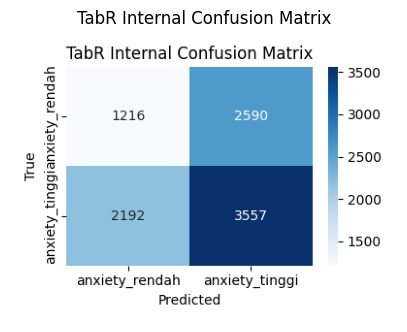

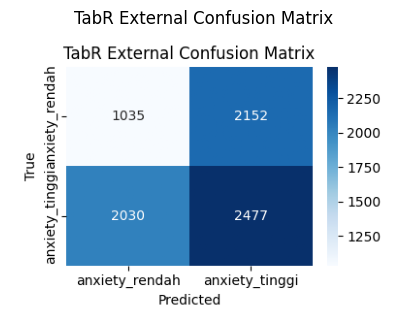


=== INTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score      support
0              0.356808  0.319496  0.337122  3806.000000
1              0.578656  0.618716  0.598016  5749.000000
accuracy       0.499529  0.499529  0.499529     0.499529
macro avg      0.467732  0.469106  0.467569  9555.000000
weighted avg   0.490288  0.499529  0.494095  9555.000000

=== EXTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score     support
0              0.337684  0.324757  0.331094  3187.00000
1              0.535105  0.549590  0.542250  4507.00000
accuracy       0.456460  0.456460  0.456460     0.45646
macro avg      0.436394  0.437173  0.436672  7694.00000
weighted avg   0.453329  0.456460  0.454785  7694.00000


In [12]:
visualize_results(OUT_DIR)


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t29/tabr_logs/version_0/metrics.csv


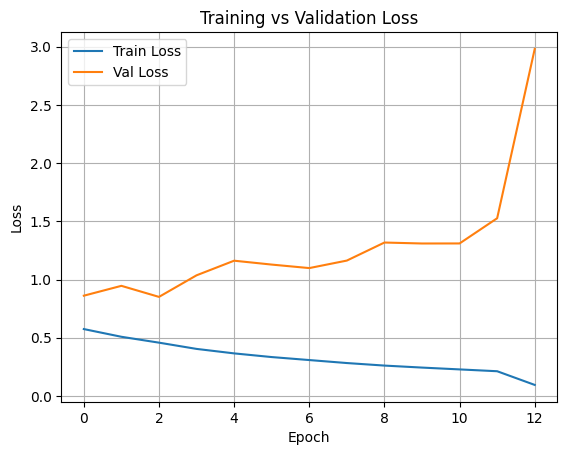

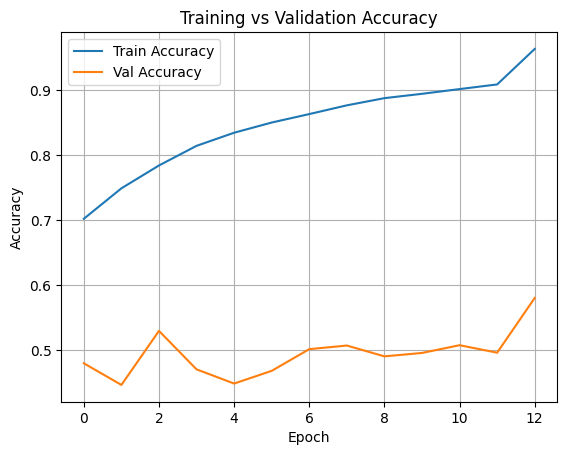

In [13]:
metrics_csv = sorted((OUT_DIR / 'tabr_logs').glob('version_*/metrics.csv'))[-1]
print(metrics_csv)
plot_lightning_metrics(metrics_csv)


In [14]:
print('Internal CM:')
print(results['internal']['cm'])
print('External CM:')
print(results['external']['cm'])


Internal CM:
[[1216 2590]
 [2192 3557]]
External CM:
[[1035 2152]
 [2030 2477]]


In [15]:
external_event_table = event_table[event_table['event_id'].isin(external_event_ids)].sort_values(['label', 'phase', 'participant', 'question', 'clip', 'event_clip'], kind='stable')
external_event_table.head(50)


,event_id,label,target,phase,participant,question,clip,event_clip
1611,after||aryan_saputra_rahmad||q1||answer_1_15d5...,anxiety_rendah,0,after,aryan_saputra_rahmad,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00007-00018
1612,after||aryan_saputra_rahmad||q1||answer_1_15d5...,anxiety_rendah,0,after,aryan_saputra_rahmad,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00023-00037
1613,after||aryan_saputra_rahmad||q1||answer_1_15d5...,anxiety_rendah,0,after,aryan_saputra_rahmad,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00091-00128
1614,after||aryan_saputra_rahmad||q1||answer_1_15d5...,anxiety_rendah,0,after,aryan_saputra_rahmad,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00158-00169
1615,after||aryan_saputra_rahmad||q1||answer_1_15d5...,anxiety_rendah,0,after,aryan_saputra_rahmad,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00183-00188
1616,after||aryan_saputra_rahmad||q2||answer_2_490a...,anxiety_rendah,0,after,aryan_saputra_rahmad,q2,answer_2_490a0a4a-d935-4509-9a4e-fb0a393be5b9_sec,event_00001-00011
1617,after||aryan_saputra_rahmad||q2||answer_2_490a...,anxiety_rendah,0,after,aryan_saputra_rahmad,q2,answer_2_490a0a4a-d935-4509-9a4e-fb0a393be5b9_sec,event_00014-00023
1618,after||aryan_saputra_rahmad||q2||answer_2_490a...,anxiety_rendah,0,after,aryan_saputra_rahmad,q2,answer_2_490a0a4a-d935-4509-9a4e-fb0a393be5b9_sec,event_00023-00035
1619,after||aryan_saputra_rahmad||q2||answer_2_490a...,anxiety_rendah,0,after,aryan_saputra_rahmad,q2,answer_2_490a0a4a-d935-4509-9a4e-fb0a393be5b9_sec,event_00235-00241
1620,after||aryan_saputra_rahmad||q2||answer_2_490a...,anxiety_rendah,0,after,aryan_saputra_rahmad,q2,answer_2_490a0a4a-d935-4509-9a4e-fb0a393be5b9_sec,event_00257-00265


In [16]:
print('=== ROW DISTRIBUTION ===')
print('train rows by label')
print(df_tr['label'].value_counts(dropna=False).sort_index())
print()
print('val rows by label')
print(df_val['label'].value_counts(dropna=False).sort_index())
print()
print('external rows by label')
print(df_external['label'].value_counts(dropna=False).sort_index())
print()
print('=== EVENT DISTRIBUTION ===')
print('train events by label')
print(df_tr[['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
print()
print('val events by label')
print(df_val[['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
print()
print('external events by label')
print(df_external[['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
print()
print('=== PHASE DISTRIBUTION ===')
print('train phase x label')
print(pd.crosstab(df_tr['phase'], df_tr['label']))
print()
print('val phase x label')
print(pd.crosstab(df_val['phase'], df_val['label']))
print()
print('external phase x label')
print(pd.crosstab(df_external['phase'], df_external['label']))
print()
print('=== PARTICIPANT DISTRIBUTION ===')
print('train unique participants by label')
print(df_tr.groupby('label')['participant'].nunique())
print()
print('val unique participants by label')
print(df_val.groupby('label')['participant'].nunique())
print()
print('external unique participants by label')
print(df_external.groupby('label')['participant'].nunique())


=== ROW DISTRIBUTION ===
train rows by label
label
anxiety_rendah    14683
anxiety_tinggi    25724
Name: count, dtype: int64

val rows by label
label
anxiety_rendah    3806
anxiety_tinggi    5749
Name: count, dtype: int64

external rows by label
label
anxiety_rendah    3187
anxiety_tinggi    4507
Name: count, dtype: int64

=== EVENT DISTRIBUTION ===
train events by label
label
anxiety_rendah     722
anxiety_tinggi    1158
Name: count, dtype: int64

val events by label
label
anxiety_rendah    214
anxiety_tinggi    273
Name: count, dtype: int64

external events by label
label
anxiety_rendah    196
anxiety_tinggi    200
Name: count, dtype: int64

=== PHASE DISTRIBUTION ===
train phase x label
label   anxiety_rendah  anxiety_tinggi
phase                                 
after            10188            8380
before            4495           17344

val phase x label
label   anxiety_rendah  anxiety_tinggi
phase                                 
after             2302            2254
before   

In [17]:
print('=== INTERNAL WITH VAL CONTEXT ===')
model.eval()
model.set_context(ctx_val_X, ctx_val_y)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
res_internal_val_ctx = evaluate_model(model, val_loader, threshold=THRESHOLD)
print(pd.DataFrame(res_internal_val_ctx['report']).transpose())
print(res_internal_val_ctx['cm'])
print()
print('=== INTERNAL WITH TRAIN CONTEXT ===')
model.set_context(ctx_train_X, ctx_train_y)
res_internal_train_ctx = evaluate_model(model, val_loader, threshold=THRESHOLD)
print(pd.DataFrame(res_internal_train_ctx['report']).transpose())
print(res_internal_train_ctx['cm'])


=== INTERNAL WITH VAL CONTEXT ===


              precision    recall  f1-score      support
0              0.413451  0.295586  0.344722  3806.000000
1              0.607697  0.722387  0.660097  5749.000000
accuracy       0.552381  0.552381  0.552381     0.552381
macro avg      0.510574  0.508986  0.502409  9555.000000
weighted avg   0.530324  0.552381  0.534475  9555.000000
[[1125 2681]
 [1596 4153]]

=== INTERNAL WITH TRAIN CONTEXT ===
              precision    recall  f1-score      support
0              0.356808  0.319496  0.337122  3806.000000
1              0.578656  0.618716  0.598016  5749.000000
accuracy       0.499529  0.499529  0.499529     0.499529
macro avg      0.467732  0.469106  0.467569  9555.000000
weighted avg   0.490288  0.499529  0.494095  9555.000000
[[1216 2590]
 [2192 3557]]
